# Option B — Comparaison de détecteurs d'anomalies

Objectif : voir si un autre détecteur non supervisé fait mieux que l'**Isolation Forest** actuel,
pour éventuellement le remplacer dans `model.py` (comme on a remplacé Gradient Boosting par TabPFN).

On compare **4 détecteurs** sur les mêmes données :

| Détecteur | Idée | Paramètres |
|---|---|---|
| **Isolation Forest** | isole les points rares par arbres aléatoires | référence actuelle |
| **ECOD** | distribution empirique par variable (queues) | **aucun** |
| **COPOD** | copule (dépendances entre variables) | **aucun** |
| **LOF** | densité locale par voisinage | nb de voisins |

> Toute la logique est dans `pyod_detectors.py` — ce notebook ne fait que l'exécuter et visualiser.

**Prérequis :** avoir généré `dataset_clean.csv` (via `01_nettoyage.ipynb` ou `python prepare_data.py`).

## 1. Charger les données et les détecteurs

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from pyod_detectors import build_detectors, compare, anomaly_scores, KPI, CONTAMINATION

df = pd.read_csv('dataset_clean.csv', parse_dates=['timestamp'])
print(f'{len(df)} mesures — KPI analysés : {KPI}')
df[KPI].describe().round(1)

137 mesures — KPI analysés : ['dl', 'ul', 'ping', 'jitter']


,dl,ul,ping,jitter
count,137.0,137.0,137.0,137.0
mean,28.8,10.4,454.4,165.7
std,24.3,17.8,294.6,295.8
min,0.4,0.1,45.0,3.1
25%,8.4,4.0,296.9,29.9
50%,21.3,7.0,359.2,66.2
75%,47.2,9.9,501.9,180.2
max,96.6,143.1,2677.2,2682.4


## 2. Combien d'anomalies chaque détecteur signale-t-il ?

Sur les données réelles (sans injection), avec une contamination attendue de 5 %.
Utile pour voir s'ils sont d'accord entre eux.

In [2]:
X = df[KPI].fillna(df[KPI].median())
for name, model in build_detectors().items():
    model.fit(X)
    flags = anomaly_scores(model, X)
    # seuil = quantile (100 - contamination%)
    thr = pd.Series(flags).quantile(1 - CONTAMINATION)
    n = int((flags >= thr).sum())
    print(f'{name:20s} : {n:2d} anomalies signalées sur {len(X)}')

Isolation Forest     :  7 anomalies signalées sur 137
ECOD                 :  7 anomalies signalées sur 137
COPOD                :  7 anomalies signalées sur 137
LOF                  :  7 anomalies signalées sur 137


## 3. Évaluation objective : injection d'anomalies

Comme personne n'a annoté les vraies anomalies, on en **fabrique** : on dégrade
volontairement 15 % du jeu de test (débit effondré, latence extrême, instabilité),
puis on mesure si chaque détecteur les retrouve. Répété 20 fois.

- **ROC-AUC** : capacité à distinguer anomalie / normal (0,5 = hasard, 0,8+ = bon).
- **PR-AUC** : idem, adapté aux anomalies rares (réf. hasard ≈ 0,15).
- **F1 (max)** : meilleur équilibre précision/rappel sur tous les seuils.

In [3]:
table = compare(df)
table

,Détecteur,ROC-AUC,PR-AUC,F1 (max)
0,ECOD,0.750,0.280,0.418
1,Isolation Forest,0.732,0.273,0.404
2,LOF,0.727,0.482,0.480
3,COPOD,0.705,0.259,0.388


## 4. Visualiser la comparaison

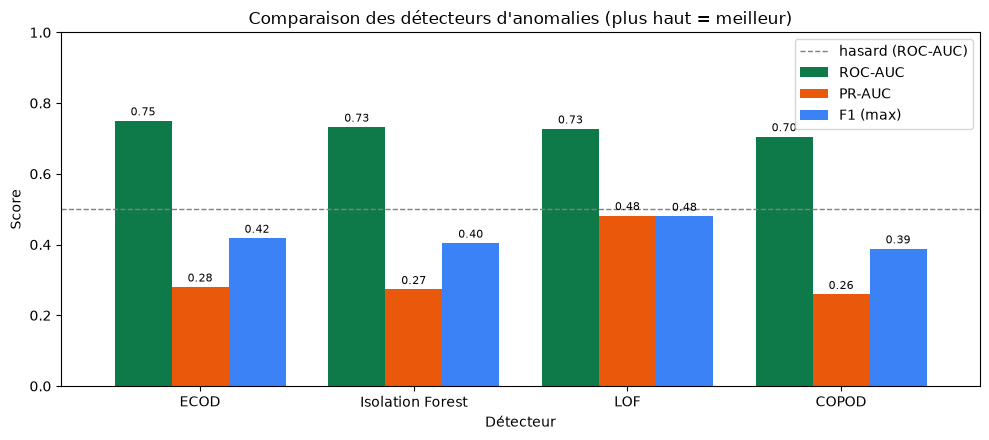

In [4]:
metrics = ['ROC-AUC', 'PR-AUC', 'F1 (max)']
ax = table.set_index('Détecteur')[metrics].plot.bar(
    figsize=(10, 4.5), rot=0, width=0.8,
    color=['#0e7a4a', '#ea580c', '#3b82f6'])
ax.set_title('Comparaison des détecteurs d\'anomalies (plus haut = meilleur)')
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.axhline(0.5, color='grey', ls='--', lw=1, label='hasard (ROC-AUC)')
ax.legend(loc='upper right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout(); plt.show()

## 5. Conclusion

Le tableau ci-dessus classe les détecteurs par ROC-AUC. À lire ainsi :

- Si un détecteur dépasse **nettement** Isolation Forest sur les trois colonnes,
  ça justifie de le remplacer dans `model.py`.
- Si les écarts sont **faibles** (quelques centièmes), le choix d'algorithme importe
  peu : le vrai levier reste la **quantité de données** et les **seuils** de décision.

> ⚠️ Rappel : les anomalies sont **fabriquées**, donc plus faciles à détecter que de
> vraies pannes. Ces scores sont une **borne supérieure optimiste**, pas la performance réelle.

**Prochaine étape possible :** si un détecteur gagne clairement, on l'intègre dans
`model.py` avec repli automatique (comme TabPFN), sans casser le reste du pipeline.